In [43]:
import numpy as np
import pandas as pd
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
import seaborn as sns

def load_file(filepath):
    dataframe = pd.read_csv(filepath, header=None, delim_whitespace=True)
    return dataframe.values

# load a list of files and return as a 3d numpy array
def load_group(filenames, prefix=''):
    loaded = list()
    for name in filenames:
        data = load_file(prefix + name)
        loaded.append(data)
    # stack group so that features are the 3rd dimension
    loaded = np.dstack(loaded)
    return loaded

# load a dataset group, such as train or test
def load_dataset_group(group, prefix=''):
    filepath = prefix + group + '/Inertial Signals/'
    # load all 9 files as a single array
    filenames = list()
    # total acceleration
    filenames += ['total_acc_x_'+group+'.txt', 'total_acc_y_'+group+'.txt', 'total_acc_z_'+group+'.txt']
    # body acceleration
    filenames += ['body_acc_x_'+group+'.txt', 'body_acc_y_'+group+'.txt', 'body_acc_z_'+group+'.txt']
    # body gyroscope
    filenames += ['body_gyro_x_'+group+'.txt', 'body_gyro_y_'+group+'.txt', 'body_gyro_z_'+group+'.txt']
    # load input data
    X = load_group(filenames, filepath)
    # load class output
    y = load_file(prefix + group + '/y_'+group+'.txt')
    return X, y


# load the dataset, returns train and test X and y elements
def load_dataset(prefix=''):
    # load all train
    trainX, trainy = load_dataset_group('train', prefix + '/content/drive/MyDrive/UCI HAR Dataset/')
    # load all test
    testX, testy = load_dataset_group('test', prefix + '/content/drive/MyDrive/UCI HAR Dataset/')

    #zero-offset class values
    trainy = trainy - 1
    testy = testy - 1
    #one hot encode y
    trainy_one_hot = to_categorical(trainy)
    testy_one_hot = to_categorical(testy)
    print(trainX.shape, trainy.shape, trainy_one_hot.shape, testX.shape, testy.shape, testy_one_hot.shape)
    return trainX, trainy, trainy_one_hot, testX, testy, testy_one_hot

trainX, trainy, trainy_one_hot, testX, testy, testy_one_hot = load_dataset()

from sklearn.model_selection import train_test_split

X_train,X_val,y_train_one_hot,y_val_one_hot,y_train,y_val=train_test_split(trainX, trainy_one_hot, trainy,test_size=0.2,random_state=100)

X_train.shape,X_val.shape,y_train_one_hot.shape,y_val_one_hot.shape,y_train.shape,y_val.shape

/tmp/ipython-input-630184846.py:8: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  dataframe = pd.read_csv(filepath, header=None, delim_whitespace=True)
/tmp/ipython-input-630184846.py:8: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  dataframe = pd.read_csv(filepath, header=None, delim_whitespace=True)
/tmp/ipython-input-630184846.py:8: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  dataframe = pd.read_csv(filepath, header=None, delim_whitespace=True)
/tmp/ipython-input-630184846.py:8: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  dataframe = pd.read_csv(filepath, header=None, delim_whitespace=True)
/tmp

(7352, 128, 9) (7352, 1) (7352, 6) (2947, 128, 9) (2947, 1) (2947, 6)


((5881, 128, 9), (1471, 128, 9), (5881, 6), (1471, 6), (5881, 1), (1471, 1))

In [44]:
n_timesteps, n_features, n_outputs = X_train.shape[1], X_train.shape[2], y_train_one_hot.shape[1]

In [45]:
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import (
    Input, Dense, Flatten, Dropout,
    Conv1D, MaxPooling1D, LSTM, concatenate
)
from tensorflow.keras.utils import to_categorical

##Level_1
# layer 1
inputs1_1= Input(shape=(n_timesteps,n_features))##128,9
conv1_1 = Conv1D(filters=128, kernel_size=3, activation='relu')(inputs1_1) ##none,126,128
# layer 2
inputs1_2= Input(shape=(n_timesteps,n_features))
conv1_2 = Conv1D(filters=128, kernel_size=5, activation='relu')(inputs1_2)##124,128
# layer 3
inputs1_3= Input(shape=(n_timesteps,n_features))
conv1_3 = Conv1D(filters=128, kernel_size=7, activation='relu')(inputs1_3)##122,128
# layer 4
inputs1_4= Input(shape=(n_timesteps,n_features))
conv1_4 = Conv1D(filters=128, kernel_size=9, activation='relu')(inputs1_4)##120,128

# merge1
merged_1 = concatenate([conv1_1,conv1_2,conv1_3,conv1_4],axis=1)

#maxpool1
pool_1=MaxPooling1D(pool_size=5)(merged_1)

##Level_2
# layer 1
conv2_1 = Conv1D(filters=64, kernel_size=3, activation='relu')(pool_1)
# layer 2
conv2_2 = Conv1D(filters=64, kernel_size=5, activation='relu')(pool_1)
# layer 3
conv2_3 = Conv1D(filters=64, kernel_size=7, activation='relu')(pool_1)
# layer 4

conv2_4 = Conv1D(filters=64, kernel_size=9, activation='relu')(pool_1)
# merge2
merged_2 = concatenate([conv2_1,conv2_2,conv2_3,conv2_4],axis=1)

#maxpool2
pool_2=MaxPooling1D(pool_size=5)(merged_2)


##Level_3
# layer 1
conv3_1 = Conv1D(filters=32, kernel_size=3, activation='relu')(pool_2)
# layer 2
conv3_2 = Conv1D(filters=32, kernel_size=5, activation='relu')(pool_2)
# layer 3
conv3_3 = Conv1D(filters=32, kernel_size=7, activation='relu')(pool_2)
# layer 4

conv3_4 = Conv1D(filters=32, kernel_size=9, activation='relu')(pool_2)
# merge2
merged_3 = concatenate([conv3_1,conv3_2,conv3_3,conv3_4],axis=1)

#maxpool2
pool_3=MaxPooling1D(pool_size=5)(merged_3)


#flatten
flat_cnn=Flatten()(pool_3)

##dense layer
dense = Dense(512, activation='relu')(flat_cnn)
outputs = Dense(n_outputs, activation='softmax')(dense)

##MODEL
cnn3_model = Model([inputs1_1, inputs1_2, inputs1_3,inputs1_4], outputs)

cnn3_model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
cnn3_model.summary()


Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_12      │ (None, 128, 9)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_13      │ (None, 128, 9)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_14      │ (None, 128, 9)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_15      │ (None, 128, 9)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_68 (Conv1D)  │ (None, 126, 128)  │      3,584 │ input_layer_12[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_69 (Conv1D)  │ (None, 124, 128)  │      5,888 │ input_layer_13[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_70 (Conv1D)  │ (None, 122, 128)  │      8,192 │ input_layer_14[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_71 (Conv1D)  │ (None, 120, 128)  │     10,496 │ input_layer_15[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_6       │ (None, 492, 128)  │          0 │ conv1d_68[0][0],  │
│ (Concatenate)       │                   │            │ conv1d_69[0][0],  │
│                     │                   │            │ conv1d_70[0][0],  │
│                     │                   │            │ conv1d_71[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_12    │ (None, 98, 128)   │          0 │ concatenate_6[0]… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_72 (Conv1D)  │ (None, 96, 64)    │     24,640 │ max_pooling1d_12… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_73 (Conv1D)  │ (None, 94, 64)    │     41,024 │ max_pooling1d_12… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_74 (Conv1D)  │ (None, 92, 64)    │     57,408 │ max_pooling1d_12… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_75 (Conv1D)  │ (None, 90, 64)    │     73,792 │ max_pooling1d_12… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_7       │ (None, 372, 64)   │          0 │ conv1d_72[0][0],  │
│ (Concatenate)       │                   │            │ conv1d_73[0][0],  │
│                     │                   │            │ conv1d_74[0][0],  │
│                     │                   │            │ conv1d_75[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_13    │ (None, 74, 64)    │          0 │ concatenate_7[0]… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_76 (Conv1D)  │ (None, 72, 32)    │      6,176 │ max_pooling1d_13… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_77 (Conv1D)  │ (None, 70, 32)    │     10,272 │ max_pooling1d_13… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_78 (Conv1D)  │ (None, 68, 32)    │     14,368 │ max_pooling1d_13

 Total params: 1,179,014 (4.50 MB)

 Trainable params: 1,179,014 (4.50 MB)

 Non-trainable params: 0 (0.00 B)

In [46]:
model_history=cnn3_model.fit(x=[X_train,X_train,X_train,X_train], y=y_train_one_hot, epochs=30, batch_size=32,validation_split=0.1)

Epoch 1/30
166/166 ━━━━━━━━━━━━━━━━━━━━ 13s 41ms/step - accuracy: 0.7880 - loss: 0.5441 - val_accuracy: 0.9525 - val_loss: 0.1080
Epoch 2/30
166/166 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9531 - loss: 0.1124 - val_accuracy: 0.9491 - val_loss: 0.1186
Epoch 3/30
166/166 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9564 - loss: 0.1021 - val_accuracy: 0.9576 - val_loss: 0.1142
Epoch 4/30
166/166 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9556 - loss: 0.1097 - val_accuracy: 0.9610 - val_loss: 0.1027
Epoch 5/30
166/166 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9485 - loss: 0.1317 - val_accuracy: 0.9491 - val_loss: 0.1380
Epoch 6/30
166/166 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9558 - loss: 0.1140 - val_accuracy: 0.9525 - val_loss: 0.1282
Epoch 7/30
166/166 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9610 - loss: 0.0954 - val_accuracy: 0.9559 - val_loss: 0.0867
Epoch 8/30
166/166 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9671 - loss: 0.0742 - val_accuracy: 

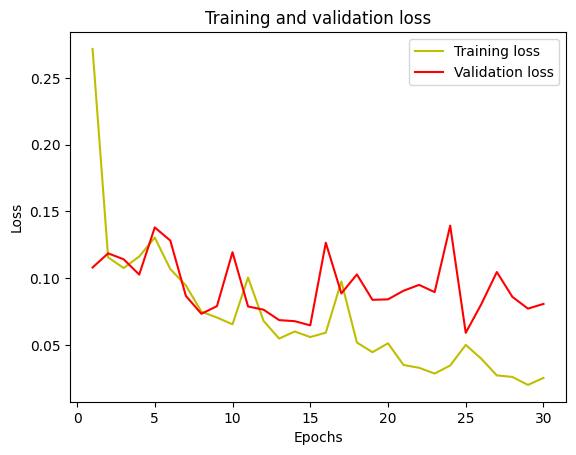

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

loss =model_history.history['loss']
val_loss =model_history.history['val_loss']
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, 'y', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

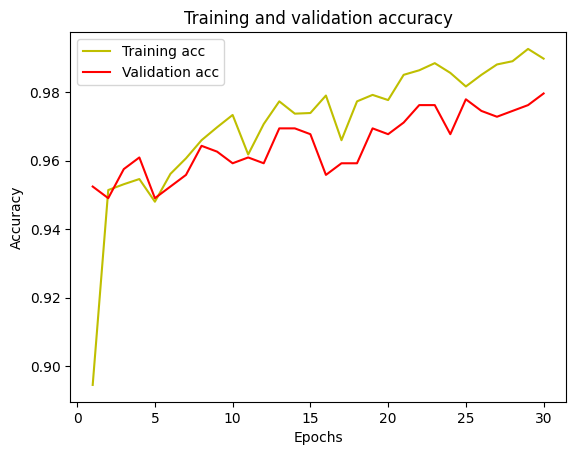

In [48]:
acc =model_history.history['accuracy']
val_acc =model_history.history['val_accuracy']
plt.plot(epochs, acc, 'y', label='Training acc')
plt.plot(epochs, val_acc, 'r', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

93/93 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step
[[487   2   6   0   1   0]
 [  1 470   0   0   0   0]
 [  1   4 415   0   0   0]
 [  0   3   0 421  62   5]
 [  0   0   0  29 503   0]
 [  0   1   0   0   0 536]]
0.9609772650152698
              precision    recall  f1-score   support

           0       1.00      0.98      0.99       496
           1       0.98      1.00      0.99       471
           2       0.99      0.99      0.99       420
           3       0.94      0.86      0.89       491
           4       0.89      0.95      0.92       532
           5       0.99      1.00      0.99       537

    accuracy                           0.96      2947
   macro avg       0.96      0.96      0.96      2947
weighted avg       0.96      0.96      0.96      2947



<Axes: >

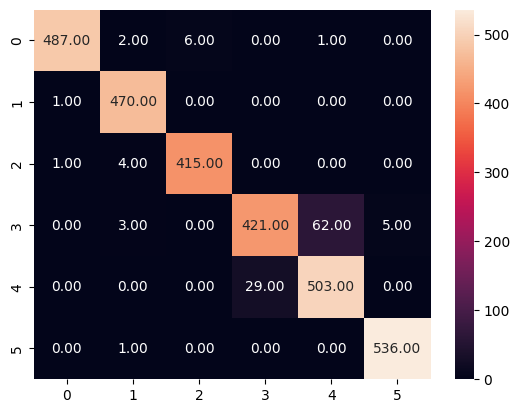

In [49]:
from sklearn.metrics import confusion_matrix,classification_report,accuracy_score
pred=cnn3_model.predict([testX,testX,testX,testX])
pred=np.argmax(pred, axis=-1)
cm=confusion_matrix(testy,pred)
print(cm)
print(accuracy_score(testy,pred))
print(classification_report(testy,pred))
sns.heatmap(cm, annot=True, fmt = '.2f')

In [50]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

In [51]:
N_TIMESTEPS = X_train.shape[1]
N_FEATURES = X_train.shape[2]
N_CLASSES = y_train_one_hot.shape[1]

In [52]:
class MultiHeadSelfAttention(tf.keras.layers.Layer):
    def __init__(self, dim, num_heads=4):
        super().__init__()
        assert dim % num_heads == 0, "hidden_dim must be divisible by num_heads"
        self.num_heads = num_heads
        self.head_dim = dim // num_heads

        self.query = layers.Dense(dim)
        self.key = layers.Dense(dim)
        self.value = layers.Dense(dim)
        self.out = layers.Dense(dim)

    def call(self, x):
        B = tf.shape(x)[0]
        N = tf.shape(x)[1]
        D = x.shape[-1]
        H = self.num_heads
        d = self.head_dim

        Q = tf.reshape(self.query(x), (B, N, H, d))
        K = tf.reshape(self.key(x), (B, N, H, d))
        V = tf.reshape(self.value(x), (B, N, H, d))

        Q = tf.transpose(Q, perm=[0, 2, 1, 3])
        K = tf.transpose(K, perm=[0, 2, 1, 3])
        V = tf.transpose(V, perm=[0, 2, 1, 3])

        attn_score = tf.matmul(Q, K, transpose_b=True) / tf.sqrt(tf.cast(d, tf.float32))
        attn_weight = tf.nn.softmax(attn_score, axis=-1)
        attn_out = tf.matmul(attn_weight, V)
        attn_out = tf.transpose(attn_out, perm=[0, 2, 1, 3])
        attn_out = tf.reshape(attn_out, (B, N, D))
        return self.out(attn_out)

class CustomTransformerEncoderLayer(tf.keras.layers.Layer):
    def __init__(self, dim, num_heads=4, ff_dim=128, dropout=0.1):
        super().__init__()
        self.attn = MultiHeadSelfAttention(dim, num_heads)
        self.norm1 = layers.LayerNormalization(epsilon=1e-6)
        self.norm2 = layers.LayerNormalization(epsilon=1e-6)
        self.ff = tf.keras.Sequential([
            layers.Dense(ff_dim, activation="relu"),
            layers.Dense(dim),
        ])
        self.dropout = layers.Dropout(dropout)

    def call(self, x, training=False):
        attn_out = self.attn(x)
        x = self.norm1(x + self.dropout(attn_out, training=training))
        ff_out = self.ff(x)
        x = self.norm2(x + self.dropout(ff_out, training=training))
        return x

In [53]:
class ResNetBlock(tf.keras.layers.Layer):
    def __init__(self, channels):
        super().__init__()
        self.conv1 = layers.Conv1D(channels, 3, padding='same')
        self.bn1 = layers.BatchNormalization()
        self.conv2 = layers.Conv1D(channels, 3, padding='same')
        self.bn2 = layers.BatchNormalization()
        self.relu = layers.ReLU()

    def call(self, x, training=False):
        residual = x
        out = self.conv1(x)
        out = self.bn1(out, training=training)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out, training=training)
        out = out + residual
        return self.relu(out)

In [54]:
# 1) Simple 1D CNN
class SimpleCNNClassifier(tf.keras.Model):
    def __init__(self, input_timesteps, input_features, num_classes, hidden=64):
        super().__init__()
        self.conv1 = layers.Conv1D(32, 3, padding='same', activation='relu')
        self.bn1 = layers.BatchNormalization()
        self.pool1 = layers.MaxPool1D(2)
        self.conv2 = layers.Conv1D(64, 3, padding='same', activation='relu')
        self.bn2 = layers.BatchNormalization()
        self.gap = layers.GlobalAveragePooling1D()
        self.fc = layers.Dense(128, activation='relu')
        self.out = layers.Dense(num_classes, activation='softmax')

    def call(self, x, training=False):
        x = self.conv1(x); x = self.bn1(x, training=training); x = self.pool1(x)
        x = self.conv2(x); x = self.bn2(x, training=training)
        x = self.gap(x)
        x = self.fc(x)
        probs = self.out(x)
        return probs

    def predict_logits(self, x, training=False):
        # convenience: return logits (before softmax)
        x = self.conv1(x); x = self.bn1(x, training=training); x = self.pool1(x)
        x = self.conv2(x); x = self.bn2(x, training=training)
        x = self.gap(x)
        x = self.fc(x)
        # build logits layer (same weights as out but without softmax)
        logits_layer = self.out
        # logits = logits_layer(x)  # this returns softmax outputs; to get logits we reconstruct Dense no activation:
        w, b = logits_layer.get_weights()
        logits = tf.matmul(x, w) + b
        return logits

In [55]:
# 2) Simple LSTM
class LSTMClassifier(tf.keras.Model):
    def __init__(self, input_timesteps, input_features, num_classes, lstm_units=64):
        super().__init__()
        self.lstm = layers.LSTM(lstm_units)
        self.fc = layers.Dense(128, activation='relu')
        self.out = layers.Dense(num_classes, activation='softmax')

    def call(self, x, training=False):
        x = self.lstm(x)
        x = self.fc(x)
        probs = self.out(x)
        return probs

    def predict_logits(self, x, training=False):
        x = self.lstm(x)
        x = self.fc(x)
        w, b = self.out.get_weights()
        logits = tf.matmul(x, w) + b
        return logits

In [56]:
# 3) CNN + LSTM
class CNNLSTMClassifier(tf.keras.Model):
    def __init__(self, input_timesteps, input_features, num_classes, cnn_filters=64, lstm_units=64):
        super().__init__()
        self.conv = layers.Conv1D(cnn_filters, 3, padding='same', activation='relu')
        self.pool = layers.MaxPool1D(2)
        self.lstm = layers.LSTM(lstm_units)
        self.fc = layers.Dense(128, activation='relu')
        self.out = layers.Dense(num_classes, activation='softmax')

    def call(self, x, training=False):
        x = self.conv(x)
        x = self.pool(x)
        x = self.lstm(x)
        x = self.fc(x)
        probs = self.out(x)
        return probs

    def predict_logits(self, x, training=False):
        x = self.conv(x)
        x = self.pool(x)
        x = self.lstm(x)
        x = self.fc(x)
        w, b = self.out.get_weights()
        logits = tf.matmul(x, w) + b
        return logits

In [57]:
# 4) ResNet (using ResNetBlock)
class ResNetClassifier(tf.keras.Model):
    def __init__(self, input_timesteps, input_features, num_classes, hidden_dim=64, num_blocks=2):
        super().__init__()
        self.conv_in = layers.Conv1D(hidden_dim, 1, padding='same', activation='relu')
        self.blocks = [ResNetBlock(hidden_dim) for _ in range(num_blocks)]
        self.gap = layers.GlobalAveragePooling1D()
        self.fc = layers.Dense(128, activation='relu')
        self.out = layers.Dense(num_classes, activation='softmax')

    def call(self, x, training=False):
        x = self.conv_in(x)
        for b in self.blocks:
            x = b(x, training=training)
        x = self.gap(x)
        x = self.fc(x)
        probs = self.out(x)
        return probs

    def predict_logits(self, x, training=False):
        x = self.conv_in(x)
        for b in self.blocks:
            x = b(x, training=training)
        x = self.gap(x)
        x = self.fc(x)
        w, b = self.out.get_weights()
        logits = tf.matmul(x, w) + b
        return logits

In [58]:
# 5) Transformer Encoder classifier
class TransformerClassifier(tf.keras.Model):
    def __init__(self, input_timesteps, input_features, num_classes, hidden_dim=64, num_layers=2, num_heads=4, ff_dim=128, dropout=0.1):
        super().__init__()
        self.proj = layers.Dense(hidden_dim)  # project features to hidden_dim
        self.transformer_layers = [
            CustomTransformerEncoderLayer(hidden_dim, num_heads, ff_dim, dropout)
            for _ in range(num_layers)
        ]
        self.gap = layers.GlobalAveragePooling1D()
        self.fc = layers.Dense(128, activation='relu')
        self.out = layers.Dense(num_classes, activation='softmax')

    def call(self, x, training=False):
        x = self.proj(x)
        for layer in self.transformer_layers:
            x = layer(x, training=training)
        x = self.gap(x)
        x = self.fc(x)
        probs = self.out(x)
        return probs

    def predict_logits(self, x, training=False):
        x = self.proj(x)
        for layer in self.transformer_layers:
            x = layer(x, training=training)
        x = self.gap(x)
        x = self.fc(x)
        w, b = self.out.get_weights()
        logits = tf.matmul(x, w) + b
        return logits

In [59]:
# 6) ResNet + Transformer (your style adapted to be fit()-compatible)
class ResNetTransformerClassifier(tf.keras.Model):
    def __init__(self, input_timesteps, input_features, num_classes, hidden_dim=64, num_resnet_blocks=2, num_transformer_layers=2, num_heads=4, ff_dim=128, dropout=0.1):
        super().__init__()
        # Input projection -> conv
        self.conv_in = layers.Conv1D(hidden_dim, 3, padding='same', activation='relu')
        self.res_blocks = [ResNetBlock(hidden_dim) for _ in range(num_resnet_blocks)]
        self.transformer_layers = [
            CustomTransformerEncoderLayer(hidden_dim, num_heads, ff_dim, dropout)
            for _ in range(num_transformer_layers)
        ]
        self.gap = layers.GlobalAveragePooling1D()
        self.fc = layers.Dense(128, activation='relu')
        self.out = layers.Dense(num_classes, activation='softmax')

    def call(self, x, training=False):
        x = self.conv_in(x)
        for b in self.res_blocks:
            x = b(x, training=training)
        for t in self.transformer_layers:
            x = t(x, training=training)
        x = self.gap(x)
        x = self.fc(x)
        probs = self.out(x)
        return probs

    def predict_logits(self, x, training=False):
        x = self.conv_in(x)
        for b in self.res_blocks:
            x = b(x, training=training)
        for t in self.transformer_layers:
            x = t(x, training=training)
        x = self.gap(x)
        x = self.fc(x)
        w, b = self.out.get_weights()
        logits = tf.matmul(x, w) + b
        return logits

In [60]:
# ============================================================
# 7) Squeeze-and-Excitation (SE) Classifier
# ============================================================
class SEBlock(tf.keras.layers.Layer):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.global_pool = layers.GlobalAveragePooling1D()
        self.fc1 = layers.Dense(channels // reduction, activation='relu')
        self.fc2 = layers.Dense(channels, activation='sigmoid')

    def call(self, x):
        se = self.global_pool(x)
        se = self.fc1(se)
        se = self.fc2(se)
        se = tf.reshape(se, (-1, 1, tf.shape(se)[-1]))
        return x * se  # 채널별 가중치 적용

class SEClassifier(tf.keras.Model):
    def __init__(self, input_timesteps, input_features, num_classes, channels=64):
        super().__init__()
        self.conv1 = layers.Conv1D(channels, 3, padding='same', activation='relu')
        self.se1 = SEBlock(channels)
        self.conv2 = layers.Conv1D(channels, 3, padding='same', activation='relu')
        self.se2 = SEBlock(channels)
        self.gap = layers.GlobalAveragePooling1D()
        self.fc = layers.Dense(128, activation='relu')
        self.out = layers.Dense(num_classes, activation='softmax')

    def call(self, x, training=False):
        x = self.conv1(x)
        x = self.se1(x)
        x = self.conv2(x)
        x = self.se2(x)
        x = self.gap(x)
        x = self.fc(x)
        return self.out(x)

    def predict_logits(self, x, training=False):
        x = self.conv1(x)
        x = self.se1(x)
        x = self.conv2(x)
        x = self.se2(x)
        x = self.gap(x)
        x = self.fc(x)
        w, b = self.out.get_weights()
        return tf.matmul(x, w) + b

In [61]:
# ============================================================
# 8) Inception (GoogleNet 스타일) Classifier
# ============================================================
class InceptionModule(tf.keras.layers.Layer):
    def __init__(self, filters=64):
        super().__init__()
        self.branch1 = layers.Conv1D(filters, 1, padding='same', activation='relu')
        self.branch3 = tf.keras.Sequential([
            layers.Conv1D(filters, 1, padding='same', activation='relu'),
            layers.Conv1D(filters, 3, padding='same', activation='relu')
        ])
        self.branch5 = tf.keras.Sequential([
            layers.Conv1D(filters, 1, padding='same', activation='relu'),
            layers.Conv1D(filters, 5, padding='same', activation='relu')
        ])
        self.pool = tf.keras.Sequential([
            layers.MaxPool1D(pool_size=3, strides=1, padding='same'),
            layers.Conv1D(filters, 1, padding='same', activation='relu')
        ])

    def call(self, x):
        b1 = self.branch1(x)
        b3 = self.branch3(x)
        b5 = self.branch5(x)
        bp = self.pool(x)
        return tf.concat([b1, b3, b5, bp], axis=-1)

class InceptionClassifier(tf.keras.Model):
    def __init__(self, input_timesteps, input_features, num_classes, filters=64):
        super().__init__()
        self.inception1 = InceptionModule(filters)
        self.inception2 = InceptionModule(filters)
        self.gap = layers.GlobalAveragePooling1D()
        self.fc = layers.Dense(128, activation='relu')
        self.out = layers.Dense(num_classes, activation='softmax')

    def call(self, x, training=False):
        x = self.inception1(x)
        x = self.inception2(x)
        x = self.gap(x)
        x = self.fc(x)
        return self.out(x)

    def predict_logits(self, x, training=False):
        x = self.inception1(x)
        x = self.inception2(x)
        x = self.gap(x)
        x = self.fc(x)
        w, b = self.out.get_weights()
        return tf.matmul(x, w) + b

In [62]:
# ============================================================
# 9) CBAM (Convolutional Block Attention Module) Classifier
# ============================================================
class CBAMBlock(tf.keras.layers.Layer):
    def __init__(self, channels, reduction=16):
        super().__init__()
        # Channel attention
        self.global_avg = layers.GlobalAveragePooling1D()
        self.global_max = layers.GlobalMaxPooling1D()
        self.fc1 = layers.Dense(channels // reduction, activation='relu')
        self.fc2 = layers.Dense(channels, activation='sigmoid')
        # Spatial attention
        self.conv_spatial = layers.Conv1D(1, kernel_size=7, padding='same', activation='sigmoid')

    def call(self, x):
        # Channel attention
        avg_pool = self.fc2(self.fc1(self.global_avg(x)))
        max_pool = self.fc2(self.fc1(self.global_max(x)))
        channel_att = tf.expand_dims(avg_pool + max_pool, axis=1)
        x = x * channel_att
        # Spatial attention
        avg_out = tf.reduce_mean(x, axis=-1, keepdims=True)
        max_out = tf.reduce_max(x, axis=-1, keepdims=True)
        spatial_att = self.conv_spatial(tf.concat([avg_out, max_out], axis=-1))
        return x * spatial_att

class CBAMClassifier(tf.keras.Model):
    def __init__(self, input_timesteps, input_features, num_classes, channels=64):
        super().__init__()
        self.conv1 = layers.Conv1D(channels, 3, padding='same', activation='relu')
        self.cbam1 = CBAMBlock(channels)
        self.conv2 = layers.Conv1D(channels, 3, padding='same', activation='relu')
        self.cbam2 = CBAMBlock(channels)
        self.gap = layers.GlobalAveragePooling1D()
        self.fc = layers.Dense(128, activation='relu')
        self.out = layers.Dense(num_classes, activation='softmax')

    def call(self, x, training=False):
        x = self.conv1(x)
        x = self.cbam1(x)
        x = self.conv2(x)
        x = self.cbam2(x)
        x = self.gap(x)
        x = self.fc(x)
        return self.out(x)

    def predict_logits(self, x, training=False):
        x = self.conv1(x)
        x = self.cbam1(x)
        x = self.conv2(x)
        x = self.cbam2(x)
        x = self.gap(x)
        x = self.fc(x)
        w, b = self.out.get_weights()
        return tf.matmul(x, w) + b

In [63]:
# -----------------------------
# Training / evaluation utilities
# -----------------------------
EPOCHS = 30
BATCH_SIZE = 32

def compile_and_fit(model, model_name, X_tr, y_tr, X_val, y_val, epochs=EPOCHS, batch_size=BATCH_SIZE):
    print(f"\n--- Training {model_name} ---")
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    callbacks = [EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)]
    history = model.fit(
        X_tr, y_tr,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        verbose=1
    )
    return history

In [64]:
# -----------------------------
# Build models dict and run experiments
# -----------------------------
models_to_train = {
    "Simple_CNN": SimpleCNNClassifier(N_TIMESTEPS, N_FEATURES, N_CLASSES),
    "LSTM": LSTMClassifier(N_TIMESTEPS, N_FEATURES, N_CLASSES),
    "CNN_LSTM": CNNLSTMClassifier(N_TIMESTEPS, N_FEATURES, N_CLASSES),
    "ResNet": ResNetClassifier(N_TIMESTEPS, N_FEATURES, N_CLASSES, hidden_dim=64, num_blocks=2),
    "Transformer": TransformerClassifier(N_TIMESTEPS, N_FEATURES, N_CLASSES, hidden_dim=64, num_layers=2),
    "ResNet_Transformer": ResNetTransformerClassifier(N_TIMESTEPS, N_FEATURES, N_CLASSES, hidden_dim=64, num_resnet_blocks=2, num_transformer_layers=2),
    "SE": SEClassifier(N_TIMESTEPS, N_FEATURES, N_CLASSES),
    "Inception": InceptionClassifier(N_TIMESTEPS, N_FEATURES, N_CLASSES),
    "CBAM": CBAMClassifier(N_TIMESTEPS, N_FEATURES, N_CLASSES)
}

history_dict = {}
test_results = {}

for name, model in models_to_train.items():
    # Build the model by calling once (helps summary for subclassed models)
    dummy = tf.random.normal((1, N_TIMESTEPS, N_FEATURES))
    _ = model(dummy, training=False)
    model.summary()
    history = compile_and_fit(model, name, X_train, y_train_one_hot, X_val, y_val_one_hot)
    history_dict[name] = history

    # Evaluate on test set
    print(f"\n--- Evaluating {name} on test set ---")
    loss, acc = model.evaluate(testX, testy_one_hot, verbose=0)
    print(f"{name} test loss: {loss:.4f}, test acc: {acc:.4f}")
    test_results[name] = acc

Model: "simple_cnn_classifier_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_80 (Conv1D)              │ (1, 128, 32)           │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (1, 128, 32)           │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_15 (MaxPooling1D) │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_81 (Conv1D)              │ (1, 64, 64)            │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (1, 64, 64)            │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_15     │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_94 (Dense)                │ (1, 128)               │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_95 (Dense)                │ (1, 6)                 │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,582 (64.77 KB)

 Trainable params: 16,390 (64.02 KB)

 Non-trainable params: 192 (768.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_107 (Conv1D)             │ (1, 128, 64)           │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cbam_block_2 (CBAMBlock)        │ ?                      │           595 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_109 (Conv1D)             │ (1, 128, 64)           │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cbam_block_3 (CBAMBlock)        │ ?                      │           595 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_25     │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_143 (Dense)               │ (1, 128)               │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_144 (Dense)               │ (1, 6)                 │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,428 (95.42 KB)

 Trainable params: 24,428 (95.42 KB)

 Non-trainable params: 0 (0.00 B)


--- Training CBAM ---
Epoch 1/30
184/184 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.5842 - loss: 1.1745 - val_accuracy: 0.8674 - val_loss: 0.3412
Epoch 2/30
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8899 - loss: 0.2820 - val_accuracy: 0.9123 - val_loss: 0.2291
Epoch 3/30
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9277 - loss: 0.1754 - val_accuracy: 0.9395 - val_loss: 0.1536
Epoch 4/30
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9424 - loss: 0.1395 - val_accuracy: 0.9402 - val_loss: 0.1441
Epoch 5/30
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9500 - loss: 0.1229 - val_accuracy: 0.9497 - val_loss: 0.1353
Epoch 6/30
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9535 - loss: 0.1180 - val_accuracy: 0.9470 - val_loss: 0.1348
Epoch 7/30
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9493 - loss: 0.1250 - val_accuracy: 0.9368 - val_loss: 0.1456
Epoch 8/30
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9536 - loss: 


=== Test accuracy summary ===
Simple_CNN          : 0.9325
LSTM                : 0.9023
CNN_LSTM            : 0.9026
ResNet              : 0.9050
Transformer         : 0.9145
ResNet_Transformer  : 0.9209
SE                  : 0.8911
Inception           : 0.9077
CBAM                : 0.9019


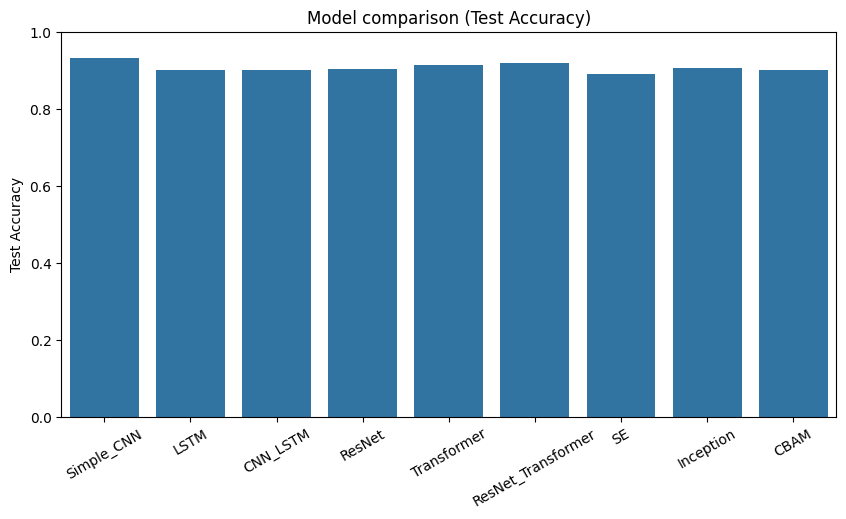

In [65]:
# -----------------------------
# Results summary
# -----------------------------
print("\n=== Test accuracy summary ===")
for k, v in test_results.items():
    print(f"{k:20s}: {v:.4f}")

# Optional: plot comparison bar chart
names = list(test_results.keys())
accs = [test_results[n] for n in names]
plt.figure(figsize=(10,5))
sns.barplot(x=names, y=accs)
plt.ylim(0,1)
plt.ylabel("Test Accuracy")
plt.title("Model comparison (Test Accuracy)")
plt.xticks(rotation=30)
plt.show()


Best model: Simple_CNN (acc=0.9325)
93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
Confusion matrix:
[[486   0  10   0   0   0]
 [  1 439  31   0   0   0]
 [  0   0 420   0   0   0]
 [  0  19   0 387  79   6]
 [  0   0   0  53 479   0]
 [  0   0   0   0   0 537]]

Classification report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99       496
           1       0.96      0.93      0.95       471
           2       0.91      1.00      0.95       420
           3       0.88      0.79      0.83       491
           4       0.86      0.90      0.88       532
           5       0.99      1.00      0.99       537

    accuracy                           0.93      2947
   macro avg       0.93      0.93      0.93      2947
weighted avg       0.93      0.93      0.93      2947



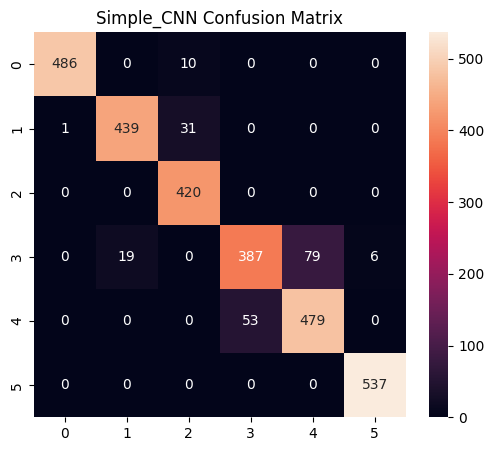

In [66]:
# Confusion matrix & classification report for best model
best_name = max(test_results, key=test_results.get)
print(f"\nBest model: {best_name} (acc={test_results[best_name]:.4f})")
best_model = models_to_train[best_name]
y_pred_prob = best_model.predict(testX)
y_pred = np.argmax(y_pred_prob, axis=1)
cm = confusion_matrix(testy, y_pred)
print("Confusion matrix:")
print(cm)
print("\nClassification report:")
print(classification_report(testy, y_pred))
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d')
plt.title(f"{best_name} Confusion Matrix")
plt.show()